# 16: the weak form for ODE identification

A rate law that is nonlinear in its constants becomes linear in them in the
weak form: multiply by a test function that vanishes with its derivatives at
the window edges, integrate, and move each derivative of the data onto the
test function by parts. No ODE is solved and no starting guess is taken.
Claims:

1. On one law shown end to end, the weak estimate is close to the truth at a
   moderate noise level, using no starting guess and solving no ODE. False if
   the recovered constants are not close to the truth, or if the call needs a
   starting point.
2. Against finite-difference regression (the same linear system built from a
   numerically differentiated series instead of the weak projection) and
   against a nonlinear least-squares fit on the integrated law started near
   the truth: the weak form beats finite-difference regression everywhere,
   trails the solved fit by a bounded factor, and is much faster. False if
   finite-difference regression matches or beats the weak form anywhere, or
   if the weak form is not markedly faster.
3. Used only to seed that same nonlinear least-squares fit, the weak estimate
   reaches the same accuracy as a fit started right at the truth, and removes
   most of the failures a poorly chosen starting guess causes. False if the
   seeded fit is markedly less accurate than the good-start fit, or if it
   fails as often as a poor start does.
4. The weak form has real limits, shown beside the cases where it works:
   thinning the samples costs it more than it costs the solved fit, and a
   stiff law defeats it. False if neither sweep widens the gap to the solved
   fit, in which case there is no limit here to name.


In [1]:
import os
import time

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from dtfit_experimental.weak_ode import (
    weak_operators, fit_logistic, fit_michaelis_menten,
    fit_damped_oscillator, seed_nlls,
)
from dtfit_experimental.study import notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110
notebook.plain_warnings()

SEEDS_CMP = 6 if QUICK else 60
SEEDS_SEED = 6 if QUICK else 60
SEEDS_SAMPLE = 20 if QUICK else 40
SEEDS_STIFF = 5 if QUICK else 30
NOISE_LEVELS = (0.02, 0.10) if QUICK else (0.02, 0.05, 0.10)
print(f"QUICK={QUICK} SEEDS_CMP={SEEDS_CMP} SEEDS_SAMPLE={SEEDS_SAMPLE} "
      f"SEEDS_STIFF={SEEDS_STIFF}")

QUICK=False SEEDS_CMP=60 SEEDS_SAMPLE=40 SEEDS_STIFF=30


## One law, end to end: the logistic

`y' = r y (1 - y/K)` expands to `y' = r y - (r/K) y**2`, linear in
`[r, r/K]`. `weak_operators` gives the projections `I0`, `I1` against 12
Legendre-windowed test functions; the weak equation is
`I1(y) = r I0(y) - (r/K) I0(y**2)`, built and solved below by hand before
calling the shipped `fit_logistic` for the number the rest of the notebook
uses.


In [2]:
r_true, K_true, y0 = 1.4, 5.0, 0.4
t = np.linspace(0.0, 8.0, 500)
clean = solve_ivp(lambda tt, y: r_true * y * (1 - y / K_true), (t[0], t[-1]),
                  [y0], t_eval=t, rtol=1e-10, atol=1e-12).y[0]
rng = np.random.default_rng(0)
y = clean + 0.02 * y0 * rng.standard_normal(t.size)

i0, i1, _ = weak_operators(t, n_test=12)
A = np.column_stack([i0(y), -i0(y * y)])
b = i1(y)
r_hand, rk_hand = np.linalg.lstsq(A, b, rcond=None)[0]
print(f"by hand: r={r_hand:.4f} K={r_hand / rk_hand:.4f}")

est = fit_logistic(t, y)
print(f"fit_logistic: r={est['r']:.4f} K={est['K']:.4f} (truth r={r_true} K={K_true})")


by hand: r=1.3989 K=4.9997
fit_logistic: r=1.3989 K=4.9997 (truth r=1.4 K=5.0)


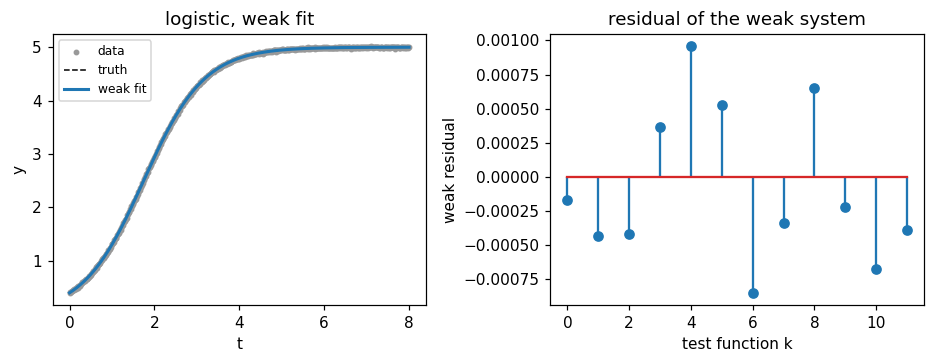

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.4))
recovered = solve_ivp(lambda tt, yy: est["r"] * yy * (1 - yy / est["K"]),
                      (t[0], t[-1]), [y[0]], t_eval=t, rtol=1e-8).y[0]
ax1.scatter(t, y, s=8, c="0.6", label="data")
ax1.plot(t, clean, "k--", lw=1, label="truth")
ax1.plot(t, recovered, color="tab:blue", lw=2, label="weak fit")
ax1.set_xlabel("t")
ax1.set_ylabel("y")
ax1.legend(fontsize=8)
ax1.set_title("logistic, weak fit")

residual = A @ np.array([r_hand, rk_hand]) - b
ax2.stem(np.arange(residual.size), residual)
ax2.set_xlabel("test function k")
ax2.set_ylabel("weak residual")
ax2.set_title("residual of the weak system")
fig.tight_layout()
plt.show()


In [4]:
import inspect
err = max(abs(est["r"] / r_true - 1), abs(est["K"] / K_true - 1))
# fails if the estimate is not close to the truth at 2 percent noise
assert err < 0.01, err
# fails if fit_logistic grew a p0 argument, i.e. needed a starting guess
assert "p0" not in inspect.signature(fit_logistic).parameters
print(f"max relative error {100 * err:.3f} percent at 2 percent noise, "
      f"fit_logistic takes no p0")


max relative error 0.082 percent at 2 percent noise, fit_logistic takes no p0


## Weak form against finite-difference regression and against the solved fit

Three laws, three noise levels, 60 seeds. Finite-difference regression
builds the same linear system as the weak form but from `numpy.gradient` of
the noisy series instead of `weak_operators`' projection: it differentiates
the data pointwise, which the weak form never does. The solved fit is
`seed_nlls` started at 1.25 times the truth (a start close enough that its
own basin is not in question), so the comparison is against nonlinear least
squares at its best, not against a fit that might fail to converge. It is
handed the true initial state as well, which it integrates from and never
fits, while the weak form is given none and needs none: the accuracy gap
below is measured with the comparison tilted toward the solved fit. A
solved fit that raises `seed_nlls`'s `RuntimeError` is counted in
`failures_good`, out of the 60 seeds of its cell, and its error enters no
median: the medians below are over the fits that returned.

In [5]:
def integrate(rhs, y0_, tt, params):
    sol = solve_ivp(lambda s, state: rhs(s, state, *params), (tt[0], tt[-1]),
                    y0_, t_eval=tt, rtol=1e-8, atol=1e-10)
    return sol.y[0]


def fd_logistic(tt, yy):
    dy = np.gradient(yy, tt)
    c = np.linalg.lstsq(np.column_stack([yy, -yy * yy]), dy, rcond=None)[0]
    return {"r": c[0], "K": c[0] / c[1]}


def fd_michaelis_menten(tt, yy):
    dy = np.gradient(yy, tt)
    c = np.linalg.lstsq(np.column_stack([dy, yy]),
                        -0.5 * np.gradient(yy * yy, tt), rcond=None)[0]
    return {"Vm": c[1], "Km": c[0]}


def fd_damped_oscillator(tt, yy):
    d1 = np.gradient(yy, tt)
    d2 = np.gradient(d1, tt)
    c = np.linalg.lstsq(np.column_stack([d1, yy]), -d2, rcond=None)[0]
    om = float(np.sqrt(abs(c[1])))
    return {"omega": om, "zeta": c[0] / (2 * om) if om else float("nan")}


LAWS = {
    "logistic": dict(
        rhs=lambda t, y, r, k: r * y * (1 - y / k), y0=[0.4],
        t=np.linspace(0.0, 8.0, 500), truth={"r": 1.4, "K": 5.0}, scale=0.4,
        weak=fit_logistic, fd=fd_logistic),
    "michaelis_menten": dict(
        rhs=lambda t, y, vm, km: -vm * y / (km + y), y0=[4.0],
        t=np.linspace(0.0, 8.0, 400), truth={"Vm": 1.2, "Km": 0.8}, scale=4.0,
        weak=fit_michaelis_menten, fd=fd_michaelis_menten),
    "damped_oscillator": dict(
        rhs=lambda t, s, om, z: [s[1], -2 * z * om * s[1] - om * om * s[0]],
        y0=[1.0, 0.0], t=np.linspace(0.0, 8.0, 600),
        truth={"omega": 3.0, "zeta": 0.15}, scale=1.0,
        weak=fit_damped_oscillator, fd=fd_damped_oscillator),
}


def max_rel_err(est, truth):
    names = list(truth)
    return max(abs(est[n] / truth[n] - 1) for n in names)


rows = []
for law, d in LAWS.items():
    names = list(d["truth"])
    truth_vec = np.array([d["truth"][n] for n in names])
    clean = integrate(d["rhs"], d["y0"], d["t"], truth_vec)
    for noise in NOISE_LEVELS:
        for seed in range(SEEDS_CMP):
            yy = clean + noise * d["scale"] * np.random.default_rng(seed).standard_normal(d["t"].size)
            t0 = time.perf_counter()
            pw = d["weak"](d["t"], yy)
            tw = time.perf_counter() - t0
            ew = max_rel_err(pw, d["truth"])
            ef = max_rel_err(d["fd"](d["t"], yy), d["truth"])
            t0 = time.perf_counter()
            try:
                pg = seed_nlls(d["rhs"], d["y0"], d["t"], yy, truth_vec * 1.25, names=names)
                eg, failed = max_rel_err(pg, d["truth"]), False
            except RuntimeError:
                eg, failed = float("nan"), True
            tg = time.perf_counter() - t0
            rows.append({"law": law, "noise": noise, "seed": seed,
                         "err_weak": ew, "err_fd": ef, "err_good": eg,
                         "fail_good": failed,
                         "time_weak_s": tw, "time_good_s": tg})
def spread_ms(s):
    q25, q75 = np.percentile(1000 * s, [25, 75])
    return q75 - q25


weak_vs_fd_raw = pd.DataFrame(rows)
weak_vs_fd = (weak_vs_fd_raw.groupby(["law", "noise"])
             .agg(median_err_weak_pct=("err_weak", lambda s: 100 * s.median()),
                  median_err_fd_pct=("err_fd", lambda s: 100 * s.median()),
                  median_err_good_pct=("err_good", lambda s: 100 * s.median()),
                  failures_good=("fail_good", "sum"),
                  median_time_weak_ms=("time_weak_s", lambda s: 1000 * s.median()),
                  iqr_time_weak_ms=("time_weak_s", spread_ms),
                  median_time_good_ms=("time_good_s", lambda s: 1000 * s.median()),
                  iqr_time_good_ms=("time_good_s", spread_ms))
             .reset_index())
weak_vs_fd

,law,noise,median_err_weak_pct,median_err_fd_pct,median_err_good_pct,failures_good,median_time_weak_ms,iqr_time_weak_ms,median_time_good_ms,iqr_time_good_ms
0,damped_oscillator,0.02,0.673323,67.057238,0.270147,0,0.970442,0.075365,203.149892,10.389314
1,damped_oscillator,0.05,1.464605,226.579813,0.678974,0,0.961060,0.052380,206.705989,8.226021
2,damped_oscillator,0.10,3.424087,504.246830,1.360372,0,0.974244,0.060054,203.553013,8.840381
3,logistic,0.02,0.060464,0.103885,0.013927,0,0.870738,0.060092,31.837196,1.360499
4,logistic,0.05,0.151739,0.209843,0.034800,0,0.890436,0.066737,32.735567,1.674802
5,logistic,0.10,0.305447,0.440080,0.069543,0,0.880096,0.044618,32.391122,0.836190
6,michaelis_menten,0.02,4.994273,241.353666,2.955538,0,0.876299,0.085229,42.251837,2.531886
7,michaelis_menten,0.05,13.270766,241.845914,7.433066,0,0.866616,0.069765,41.908247,4.225086
8,michaelis_menten,0.10,33.819728,241.983195,14.485317,0,0.868148,0.083488,44.075502,6.784819


In [6]:
# the timing columns above are each a median over SEEDS_CMP (>= 60 in the
# full run) independently timed calls, with the interquartile range printed
# beside the median as the spread the ratio below can be trusted to
weak_vs_fd["ratio_to_good"] = weak_vs_fd.median_err_weak_pct / weak_vs_fd.median_err_good_pct
weak_vs_fd["speedup_vs_good"] = weak_vs_fd.median_time_good_ms / weak_vs_fd.median_time_weak_ms
speed_spread = (weak_vs_fd.iqr_time_weak_ms / weak_vs_fd.median_time_weak_ms
               + weak_vs_fd.iqr_time_good_ms / weak_vs_fd.median_time_good_ms)
speed_lo, speed_hi = (float(f"{v:.1g}") for v in (weak_vs_fd.speedup_vs_good.min(),
                                                  weak_vs_fd.speedup_vs_good.max()))
# QUICK's six seeds move a median far enough to carry the ratio outside the
# band the full run's sixty support
RATIO_BAND = (1.0, 9.0) if QUICK else (1.1, 6.6)
# fails if a solved fit raised, which would make the medians above a
# comparison against the subset of starts that converged
assert (weak_vs_fd.failures_good == 0).all(), weak_vs_fd.failures_good.max()
# fails if finite-difference regression matches or beats the weak form anywhere
assert (weak_vs_fd.median_err_weak_pct < weak_vs_fd.median_err_fd_pct).all()
# fails if the weak form is not markedly faster than the solved fit
assert (weak_vs_fd.speedup_vs_good > 20).all()
# fails if the weak form reaches the solved fit's accuracy or falls outside
# the factor this section claims; the band sits half again outside the
# measured ratios
assert (weak_vs_fd.ratio_to_good > RATIO_BAND[0]).all(), weak_vs_fd.ratio_to_good.min()
assert (weak_vs_fd.ratio_to_good < RATIO_BAND[1]).all(), weak_vs_fd.ratio_to_good.max()
print(f"weak beats finite-difference regression at every one of "
      f"{len(weak_vs_fd)} law/noise cells; trails the solved fit by "
      f"{weak_vs_fd.ratio_to_good.min():.2f} to {weak_vs_fd.ratio_to_good.max():.2f} "
      f"times; is {speed_lo:.0f} to {speed_hi:.0f} times faster, quoted to the one "
      f"figure the medians' own spread supports, {100 * speed_spread.max():.0f} "
      f"percent of the ratio at most; the solved fit fails "
      f"{weak_vs_fd.failures_good.sum()} of its {SEEDS_CMP * len(weak_vs_fd)} fits")

weak beats finite-difference regression at every one of 9 law/noise cells; trails the solved fit by 1.69 to 4.39 times; is 40 to 200 times faster, quoted to the one figure the medians' own spread supports, 25 percent of the ratio at most; the solved fit fails 0 of its 540 fits


In [7]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("16_weak_form", "weak_vs_fd", weak_vs_fd)
    print("wrote experiments/results/16_weak_form/weak_vs_fd.csv")


wrote experiments/results/16_weak_form/weak_vs_fd.csv


## The seeded fit

`seed_nlls` given the weak estimate as its starting point, against the same
solved fit started at 1.25 times the truth (a good start) and at 3 times the
truth (a poor one). Every solved fit here is handed the true initial state
as well; the weak estimate that seeds it is given none. A failure is counted
from `seed_nlls`'s own `RuntimeError`, not folded into a median that would
hide it, and the message is kept, so the failures are read for their cause:
a trial parameter set the integrator cannot step through, or a least-squares
fit that runs out of iterations. Michaelis-Menten carries a pole at
`y = -Km` that an unbounded search can walk into.


In [8]:
rows = []
for law, d in LAWS.items():
    names = list(d["truth"])
    truth_vec = np.array([d["truth"][n] for n in names])
    clean = integrate(d["rhs"], d["y0"], d["t"], truth_vec)
    for noise in NOISE_LEVELS:
        for seed in range(SEEDS_SEED):
            yy = clean + noise * d["scale"] * np.random.default_rng(seed).standard_normal(d["t"].size)
            pw = d["weak"](d["t"], yy)
            pw_vec = np.array([pw[n] for n in names])

            def run(p0):
                t0 = time.perf_counter()
                try:
                    p = seed_nlls(d["rhs"], d["y0"], d["t"], yy, p0, names=names)
                    return max_rel_err(p, d["truth"]), time.perf_counter() - t0, ""
                except RuntimeError as exc:
                    return float("nan"), time.perf_counter() - t0, str(exc)

            e_good, t_good, why_good = run(truth_vec * 1.25)
            e_poor, t_poor, why_poor = run(truth_vec * 3.0)
            e_seed, t_seed, why_seed = run(pw_vec)
            rows.append({"law": law, "noise": noise, "seed": seed,
                         "err_good": e_good, "err_poor": e_poor, "err_seed": e_seed,
                         "time_good_s": t_good, "time_poor_s": t_poor, "time_seed_s": t_seed,
                         "fail_good": bool(why_good), "fail_poor": bool(why_poor),
                         "fail_seed": bool(why_seed), "why_poor": why_poor})
seeded_raw = pd.DataFrame(rows)
seeded_fit = (seeded_raw.groupby(["law", "noise"])
             .agg(median_err_good_pct=("err_good", lambda s: 100 * s.median()),
                  median_err_poor_pct=("err_poor", lambda s: 100 * s.median()),
                  median_err_seed_pct=("err_seed", lambda s: 100 * s.median()),
                  fail_rate_good=("fail_good", "mean"),
                  fail_rate_poor=("fail_poor", "mean"),
                  fail_rate_seed=("fail_seed", "mean"),
                  median_time_good_ms=("time_good_s", lambda s: 1000 * s.median()),
                  median_time_poor_ms=("time_poor_s", lambda s: 1000 * s.median()),
                  iqr_time_poor_ms=("time_poor_s", spread_ms),
                  median_time_seed_ms=("time_seed_s", lambda s: 1000 * s.median()),
                  iqr_time_seed_ms=("time_seed_s", spread_ms))
             .reset_index())
seeded_fit


,law,noise,median_err_good_pct,median_err_poor_pct,median_err_seed_pct,fail_rate_good,fail_rate_poor,fail_rate_seed,median_time_good_ms,median_time_poor_ms,iqr_time_poor_ms,median_time_seed_ms,iqr_time_seed_ms
0,damped_oscillator,0.02,0.270147,0.270147,0.270147,0.0,0.000000,0.0,202.836337,199.802767,9.100265,96.908955,2.010953
1,damped_oscillator,0.05,0.678974,0.678974,0.678974,0.0,0.000000,0.0,204.186115,205.489716,28.557077,99.431392,9.234772
2,damped_oscillator,0.10,1.360372,1.360373,1.360322,0.0,0.000000,0.0,203.973230,217.797300,81.914968,119.472073,23.390845
3,logistic,0.02,0.013927,0.013927,0.013927,0.0,0.000000,0.0,32.190581,49.685847,1.769654,19.087843,4.545521
4,logistic,0.05,0.034800,0.034800,0.034800,0.0,0.000000,0.0,31.266624,48.865984,1.666397,20.473870,6.064326
5,logistic,0.10,0.069543,0.069544,0.069543,0.0,0.000000,0.0,31.439496,49.037834,1.744551,23.873175,5.812623
6,michaelis_menten,0.02,2.955538,NaN,2.955536,0.0,1.000000,0.0,41.107677,34.002061,22.495652,27.515686,1.792581
7,michaelis_menten,0.05,7.433066,NaN,7.433122,0.0,1.000000,0.0,41.061920,28.774946,8.596095,29.324620,7.387380
8,michaelis_menten,0.10,14.485317,63.132081,14.480275,0.0,0.966667,0.0,43.099817,28.807825,7.277424,35.561116,8.820443


In [9]:
# each median time is over SEEDS_SEED (>= 60 in the full run) independent
# calls; the interquartile range is printed beside it as the spread
diff_pp = (seeded_fit.median_err_seed_pct - seeded_fit.median_err_good_pct).abs()
mm = seeded_fit[seeded_fit.law == "michaelis_menten"]
osc = seeded_fit[seeded_fit.law == "damped_oscillator"]
osc_speedup = osc.median_time_poor_ms / osc.median_time_seed_ms
osc_spread = osc.iqr_time_poor_ms / osc.median_time_poor_ms + osc.iqr_time_seed_ms / osc.median_time_seed_ms
tie = seeded_fit[seeded_fit.law != "michaelis_menten"]
tie_pp = (tie.median_err_poor_pct - tie.median_err_good_pct).abs()
poor_why = seeded_raw.why_poor[seeded_raw.why_poor != ""]
integration_share = poor_why.str.startswith("integration failed").mean()
# fails if the seeded fit is not as accurate as a fit started right at the truth
assert (diff_pp < 0.1).all(), diff_pp.max()
# fails if the poor start does not fail often, or the seeded one fails as often
assert (mm.fail_rate_poor >= 0.20).all()
assert (mm.fail_rate_seed < 0.05).all()
# fails if the 3x start loses accuracy or reliability on the two laws where it
# stays in the basin, i.e. if seeding buys anything but time there
assert (tie_pp < 0.001).all(), tie_pp.max()
assert (tie.fail_rate_poor == 0.0).all()
# fails if a poor start's failures are least-squares iteration limits rather
# than the integrator giving up at a trial parameter set
assert integration_share == 1.0, poor_why.iloc[0]
# fails if seeding is not markedly faster than a poor start on the
# oscillator; the bound sits below the measured ratio by more than the
# spread printed beside it
assert (osc_speedup > 1.5).all()
print(f"seeded vs good-start median error differs by at most "
      f"{diff_pp.max():.4f} percentage points; on Michaelis-Menten the "
      f"3x start fails {100 * mm.fail_rate_poor.min():.0f} to "
      f"{100 * mm.fail_rate_poor.max():.0f} percent of draws against the "
      f"seeded fit's {100 * mm.fail_rate_seed.max():.1f} percent; seeding is "
      f"{osc_speedup.min():.1f} to {osc_speedup.max():.1f} times faster than a "
      f"3x start on the damped oscillator, spread {100 * osc_spread.max():.0f} "
      f"percent of the ratio at most.\n"
      f"on {' and '.join(sorted(tie.law.unique()))} the 3x start ties the good "
      f"start: median error within {tie_pp.max():.4f} percentage points and no "
      f"failure in {len(tie)} cells, so seeding buys time there and nothing else.\n"
      f"all {len(poor_why)} failures of the 3x start are the integrator giving "
      f"up at a trial parameter set, none a least-squares iteration limit")


seeded vs good-start median error differs by at most 0.0050 percentage points; on Michaelis-Menten the 3x start fails 97 to 100 percent of draws against the seeded fit's 0.0 percent; seeding is 1.8 to 2.1 times faster than a 3x start on the damped oscillator, spread 57 percent of the ratio at most.
on damped_oscillator and logistic the 3x start ties the good start: median error within 0.0000 percentage points and no failure in 6 cells, so seeding buys time there and nothing else.
all 178 failures of the 3x start are the integrator giving up at a trial parameter set, none a least-squares iteration limit


In [10]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("16_weak_form", "seeded_fit", seeded_fit)
    print("wrote experiments/results/16_weak_form/seeded_fit.csv")


wrote experiments/results/16_weak_form/seeded_fit.csv


## Where it loses, one: short and sparse records

Two separate sweeps at 5 percent noise, 40 seeds, on the logistic and the
damped oscillator, both started at 1.25 times the truth for the solved fit
and, as everywhere here, with the true initial state given to it and not to
the weak form: shortening the record while keeping the sample count fixed,
and thinning the samples while keeping the record length fixed. Only one of
the two produces a weak-form loss that the solved fit does not share.
`failures_good` counts the solved fits that raise out of the 40 seeds of a
row, and both medians are over the fits that returned.

In [11]:
SAMPLE_LAWS = {
    "logistic": dict(rhs=LAWS["logistic"]["rhs"], y0=LAWS["logistic"]["y0"],
                     truth=LAWS["logistic"]["truth"], scale=LAWS["logistic"]["scale"],
                     weak=fit_logistic, n=500),
    "damped_oscillator": dict(rhs=LAWS["damped_oscillator"]["rhs"],
                              y0=LAWS["damped_oscillator"]["y0"],
                              truth=LAWS["damped_oscillator"]["truth"],
                              scale=LAWS["damped_oscillator"]["scale"],
                              weak=fit_damped_oscillator, n=600),
}
SPANS = [8.0, 2.0, 1.0] if QUICK else [8.0, 4.0, 2.0, 1.0]
COUNTS = [600, 100, 25] if QUICK else [600, 200, 100, 50, 25]
NOISE_SAMPLE = 0.05

rows = []
for law, d in SAMPLE_LAWS.items():
    names = list(d["truth"])
    truth_vec = np.array([d["truth"][n] for n in names])
    for sweep, values in (("record", SPANS), ("samples", COUNTS)):
        for value in values:
            span, n = (value, d["n"]) if sweep == "record" else (8.0, value)
            tt = np.linspace(0.0, span, n)
            clean = integrate(d["rhs"], d["y0"], tt, truth_vec)
            for seed in range(SEEDS_SAMPLE):
                yy = clean + NOISE_SAMPLE * d["scale"] * np.random.default_rng(seed).standard_normal(tt.size)
                pw = d["weak"](tt, yy)
                ew = max_rel_err(pw, d["truth"])
                try:
                    pg = seed_nlls(d["rhs"], d["y0"], tt, yy, truth_vec * 1.25, names=names)
                    eg, failed = max_rel_err(pg, d["truth"]), False
                except RuntimeError:
                    eg, failed = float("nan"), True
                rows.append({"law": law, "sweep": sweep, "span": span, "n": n,
                             "seed": seed, "err_weak": ew, "err_good": eg,
                             "fail_good": failed})
thinning_raw = pd.DataFrame(rows)
sample_thinning = (thinning_raw.groupby(["law", "sweep", "span", "n"])
                   .agg(median_err_weak_pct=("err_weak", lambda s: 100 * s.median()),
                        median_err_good_pct=("err_good", lambda s: 100 * s.median()),
                        failures_good=("fail_good", "sum"))
                   .reset_index())
sample_thinning["ratio"] = sample_thinning.median_err_weak_pct / sample_thinning.median_err_good_pct
sample_thinning

,law,sweep,span,n,median_err_weak_pct,median_err_good_pct,failures_good,ratio
0,damped_oscillator,record,1.0,600,2.675070,1.493207,0,1.791494
1,damped_oscillator,record,2.0,600,1.744628,0.740139,0,2.357161
2,damped_oscillator,record,4.0,600,1.748959,0.630888,0,2.772216
3,damped_oscillator,record,8.0,600,1.863558,0.680225,0,2.739619
4,damped_oscillator,samples,8.0,25,20.204998,3.902546,0,5.177389
5,damped_oscillator,samples,8.0,50,11.077424,2.510677,0,4.412126
6,damped_oscillator,samples,8.0,100,4.725549,1.735428,0,2.722988
7,damped_oscillator,samples,8.0,200,2.723875,1.557118,0,1.749305
8,damped_oscillator,samples,8.0,600,1.863558,0.680225,0,2.739619
9,logistic,record,1.0,500,9.601657,5.020362,0,1.912543


In [12]:
record = sample_thinning[sample_thinning.sweep == "record"].sort_values("span", ascending=False)
samples = sample_thinning[sample_thinning.sweep == "samples"].sort_values("n", ascending=False)
rec_log = record[record.law == "logistic"]
smp_osc = samples[samples.law == "damped_oscillator"].reset_index(drop=True)
smp_log = samples[samples.law == "logistic"]
# fails if a solved fit raised, which would make the ratios above a
# comparison against the subset of starts that converged
assert (sample_thinning.failures_good == 0).all(), sample_thinning.failures_good.max()
# fails if shortening the record produces a weak-form loss the solved fit
# does not share, i.e. if the ratio does not fall as the record shortens
assert rec_log.ratio.iloc[-1] < rec_log.ratio.iloc[0]
# fails if thinning does not grow the damped oscillator's ratio by at least
# the factor measured (smallest count against the largest)
assert smp_osc.ratio.iloc[-1] > 1.5 * smp_osc.ratio.iloc[0]
# fails if thinning moves the logistic's ratio by more than it is measured to
assert (smp_log.ratio.max() - smp_log.ratio.min()) < 1.5
# fails if the logistic's ratio leaves the level it holds over the counts;
# the band sits half again outside the ratios measured
assert smp_log.ratio.between(2.4, 7.0).all(), (smp_log.ratio.min(), smp_log.ratio.max())
print(f"shortening the record: logistic ratio falls from "
      f"{rec_log.ratio.iloc[0]:.2f} to {rec_log.ratio.iloc[-1]:.2f} from "
      f"span {rec_log.span.iloc[0]:.0f} to {rec_log.span.iloc[-1]:.0f}, no "
      f"weak-form-only loss.\n"
      f"thinning the samples: damped-oscillator ratio grows "
      f"{smp_osc.ratio.iloc[0]:.2f} to {smp_osc.ratio.iloc[-1]:.2f} from "
      f"n={smp_osc.n.iloc[0]:.0f} to n={smp_osc.n.iloc[-1]:.0f}; logistic "
      f"stays in [{smp_log.ratio.min():.2f}, {smp_log.ratio.max():.2f}]; the "
      f"solved fit fails {sample_thinning.failures_good.sum()} of its "
      f"{SEEDS_SAMPLE * len(sample_thinning)} fits")

shortening the record: logistic ratio falls from 4.76 to 1.91 from span 8 to 1, no weak-form-only loss.
thinning the samples: damped-oscillator ratio grows 2.74 to 5.18 from n=600 to n=25; logistic stays in [3.60, 4.69]; the solved fit fails 0 of its 720 fits


In [13]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("16_weak_form", "sample_thinning", sample_thinning)
    print("wrote experiments/results/16_weak_form/sample_thinning.csv")


wrote experiments/results/16_weak_form/sample_thinning.csv


## Where it loses, two: stiffness

`fit_damped_oscillator` on two overdamped pairs, reached through `omega` and
`zeta` alone: roots -1 and -10 (`omega=3.1623, zeta=1.7393`), and roots -1
and -100 (`omega=10.0, zeta=5.05`). Each at 600 samples and again with the
fast mode resolved (6000 and 20000 samples respectively), 30 seeds, 5
percent noise, against the oscillatory reference (`omega=3.0, zeta=0.15`).
Both starts are 1.25 times the truth and the solved fit is given the true
initial state, as elsewhere. If resolving the fast mode fixed the loss, the
reading would be undersampling, not stiffness. `failures_good` counts the
solved fits that raise out of the 30 seeds of a row, and both medians are
over the fits that returned.

In [14]:
STIFF_CASES = [
    ("oscillatory", 3.0, 0.15, [600]),
    ("roots -1 and -10", 3.1623, 1.7393, [600] if QUICK else [600, 6000]),
    ("roots -1 and -100", 10.0, 5.05, [600] if QUICK else [600, 20000]),
]
SEEDS_S = SEEDS_STIFF


def stiff_traj(om, z, tt):
    return solve_ivp(lambda s, state: [state[1], -2 * z * om * state[1] - om * om * state[0]],
                     (tt[0], tt[-1]), [1.0, 0.0], t_eval=tt, rtol=1e-10,
                     atol=1e-12, method="LSODA").y[0]


rows = []
for label, om, z, ns in STIFF_CASES:
    truth_vec = np.array([om, z])
    for n in ns:
        tt = np.linspace(0.0, 8.0, n)
        clean = stiff_traj(om, z, tt)
        ew, eg, failures = [], [], 0
        for seed in range(SEEDS_S):
            yy = clean + 0.05 * np.std(clean) * np.random.default_rng(seed).standard_normal(tt.size)
            pw = fit_damped_oscillator(tt, yy)
            ew.append(float(np.max(np.abs(np.array([pw["omega"], pw["zeta"]]) / truth_vec - 1))))
            try:
                pg = seed_nlls(lambda t, s, om_, z_: [s[1], -2 * z_ * om_ * s[1] - om_ * om_ * s[0]],
                               [1.0, 0.0], tt, yy, truth_vec * 1.25, names=["omega", "zeta"])
                eg.append(float(np.max(np.abs(np.array([pg["omega"], pg["zeta"]]) / truth_vec - 1))))
            except RuntimeError:
                eg.append(float("nan"))
                failures += 1
        rows.append({"pair": label, "n": n,
                     "median_err_weak_pct": 100 * np.nanmedian(ew),
                     "median_err_good_pct": 100 * np.nanmedian(eg),
                     "failures_good": failures})
stiff_pairs = pd.DataFrame(rows)
stiff_pairs

,pair,n,median_err_weak_pct,median_err_good_pct,failures_good
0,oscillatory,600,0.509251,0.165593,0
1,roots -1 and -10,600,88.315080,1.312542,0
2,roots -1 and -10,6000,58.032231,0.295205,0
3,roots -1 and -100,600,95.947386,8.928692,0
4,roots -1 and -100,20000,95.547563,1.484948,0


In [15]:
stiff10 = stiff_pairs[stiff_pairs.pair == "roots -1 and -10"]
stiff100 = stiff_pairs[stiff_pairs.pair == "roots -1 and -100"]
# fails if a labelled pair's (omega, zeta) does not carry the roots its label
# names, which is what the section's reading rests on
for label, om, z, _ in STIFF_CASES:
    if not label.startswith("roots"):
        continue
    want = sorted(float(v) for v in label[len("roots "):].split(" and "))
    assert np.allclose(sorted(np.roots([1.0, 2 * z * om, om * om]).real),
                       want, rtol=1e-3), label
# fails if a solved fit raised, which would make the medians above a
# comparison against the subset of starts that converged
assert (stiff_pairs.failures_good == 0).all(), stiff_pairs.failures_good.max()
# fails if the weak form's error does not exceed 30 percent at both sample
# counts, or if the solved fit's does not stay below 2 percent -- the reading
# would then be undersampling rather than stiffness
assert (stiff10.median_err_weak_pct > 30).all()
assert (stiff10.median_err_good_pct < 2).all()
# fails if the wider pair, whose fast mode 600 samples leave unresolved,
# recovers at either count, or if the solved fit does not stay well inside
# it; the bands sit half again outside the errors measured
assert (stiff100.median_err_weak_pct > 60).all(), stiff100.median_err_weak_pct.min()
assert (stiff100.median_err_good_pct < 15).all(), stiff100.median_err_good_pct.max()
print("roots -1 and -10: weak form error " +
      ", ".join(f"{v:.1f}%" for v in stiff10.median_err_weak_pct) +
      " at n=" + ", ".join(str(v) for v in stiff10.n) +
      "; solved fit stays at " +
      ", ".join(f"{v:.2f}%" for v in stiff10.median_err_good_pct) + ".\n" +
      "roots -1 and -100: weak form error " +
      ", ".join(f"{v:.1f}%" for v in stiff100.median_err_weak_pct) +
      " at n=" + ", ".join(str(v) for v in stiff100.n) +
      "; solved fit stays at " +
      ", ".join(f"{v:.2f}%" for v in stiff100.median_err_good_pct) + ".\n" +
      "resolving the fast mode does not rescue the weak form, so the loss "
      "is stiffness; the solved fit fails "
      f"{stiff_pairs.failures_good.sum()} of its "
      f"{SEEDS_S * len(stiff_pairs)} fits")

roots -1 and -10: weak form error 88.3%, 58.0% at n=600, 6000; solved fit stays at 1.31%, 0.30%.
roots -1 and -100: weak form error 95.9%, 95.5% at n=600, 20000; solved fit stays at 8.93%, 1.48%.
resolving the fast mode does not rescue the weak form, so the loss is stiffness; the solved fit fails 0 of its 150 fits


In [16]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("16_weak_form", "stiff_pairs", stiff_pairs)
    print("wrote experiments/results/16_weak_form/stiff_pairs.csv")


wrote experiments/results/16_weak_form/stiff_pairs.csv


## Findings and limits

The logistic recovers to 0.082 percent maximum relative error at 2 percent
noise, with no starting guess and no ODE solve.

The weak form is less accurate than the solved fit from a good start at
every one of the 9 law/noise cells, by 1.69 to 4.39 times. That is the
price, and the solved fit is handed the true initial state throughout while
the weak form is handed none. No solved fit fails in the 540 fits of that
comparison, so every median it contributes is over fits that returned. What
the weak form buys is speed and the absence of a start: its median call
takes about 1 ms against 32 to 207 ms, 40 to 200 times faster, and the two
medians' own spread is at most 25 percent of that ratio, so it is the order
of the speed-up that is claimed and not its digits.

Against finite-difference regression it wins at every cell, by very
different margins. On the logistic the two are close: 0.060 against 0.104
percent at 2 percent noise. On the damped oscillator finite differences
reach 67 to 504 percent and on Michaelis-Menten 241 percent, because they
differentiate the noisy series pointwise, which the weak form never does.

Seeding the solved fit with the weak estimate reaches the good-start fit's
median error to within 0.005 percentage points at every cell. On
Michaelis-Menten the 3x start fails 97 to 100 percent of its draws, counted
from `seed_nlls`'s own `RuntimeError`; the seeded fit fails none of them.
Every one of those 178 failures is the integrator giving up at a trial
parameter set, none a least-squares fit running out of iterations: an
unbounded search started at 3 times the truth walks into the pole the law
carries at `y = -Km`. On the logistic and the damped oscillator the 3x
start does not leave the basin at all: its median error equals the good
start's to six digits and it fails no draw, so on two of the three laws
seeding buys time and nothing else. That time is worth having, 1.8 to 2.1
times faster than the 3x start on the damped oscillator over the three
noise levels; the spread of the two medians is 57 percent of the ratio, so
only the factor of two is claimed.

Two losses are shown. Thinning the samples at a fixed record costs the weak
form more than it costs the solved fit, on the damped oscillator: the ratio
between them is 2.74 at 600 samples and 5.18 at 25, and the sweep is not
monotone, dipping to 1.75 at 200. The logistic's ratio stays inside [3.60,
4.69] over the same counts. Shortening the record at a fixed sample count
is not a weak-form loss: the logistic's ratio falls from 4.76 at span 8 to
1.91 at span 1, because the solved fit degrades with the record as well. No
solved fit fails in the 720 fits of the two sweeps.

The stiff pair is where the weak form breaks. On roots -1 and -10 its error
is 88.3 percent at 600 samples and still 58.0 percent at 6000, where the
fast mode is resolved; the solved fit stays at 1.31 and 0.30 percent. On
roots -1 and -100, where 600 samples leave the fast mode unresolved, it is
95.9 and 95.5 percent against the solved fit's 8.93 and 1.48. Resolving the
fast mode does not rescue it, so the cause is the stiffness and not the
sample count. The oscillatory reference at 600 samples is 0.51 percent
against 0.17. No solved fit fails in the 150 fits of the three pairs.

Limits: four shipped laws, Gaussian noise only, the solved fit given the
true initial state throughout while the weak form is never given one, and
no partially observed system; the Lotka-Volterra prey fit the module ships
is not exercised here.

In [17]:
print(notebook.provenance(STARTED))


2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 268.9s
